> **Retired, 2026-07-28.** Superseded by
> `notebooks/environmental_data/av1_grouped_category_importance.ipynb`, which covers the same
> correlation/SHAP/Elastic-Net ground plus stand-structure (silvicultural) variables in one
> unified feature set, adds grouped permutation importance and Moran's I before/after, and fixes
> a SHAP test-set leakage bug present when this notebook was last run. Left here unmaintained
> (not deleted, not updated) -- its numbers reflect the environmental-only feature set and
> should not be treated as current. Go to the new notebook instead.


# Environmental Variable Importance (Tier 2) -- what actually matters, and why

`av1_aux_data_resolution_check.ipynb` (Tier 1) extracted and screened every candidate environmental
variable -- terrain, wind, soil, climate, and spatial-lag neighbour features -- and checked how
they correlate with each other. This notebook is the next step: a real fitted model (XGBoost,
`models/xgb_environmental/`) and SHAP tell us which variables actually matter for predicting the
Chapman-Richards residual, and how much. That combination -- correlation redundancy plus real
model evidence -- is what decides the candidate feature list for Env-PINN's sub-network.

**Primary cohort: 4survey** (71,766 plots, the dissertation's main spatial-attribution cohort).
6survey is referenced where it changes the picture -- never trusted alone, per this repo's own
established convention.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from scipy.stats import spearmanr

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from models.common.geo import load_compartment_boundaries
from models.xgb_environmental.xgb_environmental import FEATURE_PROVENANCE, FEATURE_SETS

pd.set_option("display.max_columns", 60)
# pd.set_option("display.width", 160)

PRIMARY_COHORT = "4survey"
SECONDARY_COHORT = "6survey"

print("project_root:", project_root)


project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


## 1. Load everything: features, SHAP values, metrics

Reads the Tier 1 export (every environmental variable, one row per plot) and the Tier 2 model
outputs (`models/xgb_environmental/run_xgb_environmental.py`'s saved metrics + SHAP values) --
nothing is recomputed here, this notebook only reads and interprets what those two steps already
produced.


In [2]:
features_df = pd.read_parquet(project_root / "data/processed/environmental/plot_environmental_features.parquet")
compartment_boundaries = load_compartment_boundaries()

def load_model_outputs(feature_set_name, cohort):
    output_dir = project_root / "outputs" / "spatial_block" / "xgb_environmental" / feature_set_name / cohort
    import json
    metrics = json.loads((output_dir / "metrics.json").read_text())
    predictions = pd.read_csv(output_dir / "predictions.csv")
    shap_path = output_dir / "shap_values.parquet"
    shap_df = pd.read_parquet(shap_path) if shap_path.exists() else None
    return metrics, predictions, shap_df


metrics_all, predictions_all, shap_all = load_model_outputs("all_environmental", PRIMARY_COHORT)
metrics_no_nbr, predictions_no_nbr, shap_no_nbr = load_model_outputs("all_environmental_no_neighbour", PRIMARY_COHORT)
metrics_terrain_wind, predictions_terrain_wind, _ = load_model_outputs("terrain_and_wind_only", PRIMARY_COHORT)

print(f"all_environmental:              test R2={metrics_all['r2']:.3f}, RMSE={metrics_all['rmse']:.3f}")
print(f"all_environmental_no_neighbour: test R2={metrics_no_nbr['r2']:.3f}, RMSE={metrics_no_nbr['rmse']:.3f}")
print(f"terrain_and_wind_only:          test R2={metrics_terrain_wind['r2']:.3f}, RMSE={metrics_terrain_wind['rmse']:.3f}")


all_environmental:              test R2=0.596, RMSE=3.674
all_environmental_no_neighbour: test R2=0.187, RMSE=5.214
terrain_and_wind_only:          test R2=0.150, RMSE=5.332


In [ ]:
# Reproduces the EXACT train/val/test split run_xgb_environmental.py used (same function, same
# block column, same buffer, same seed) -- built once here, near the top, so every section below
# that needs to refit a model (ALE in section 4, ablation refits in section 6, Elastic Net in
# section 7) shares the same directly-comparable split rather than each recomputing it separately.
#
# train/val/test discipline followed everywhere below: VAL is the only split used to make a
# feature-selection or comparison decision (which cluster member to drop, which method to
# trust); TEST is read only once, at the very end of section 6, as the final, honest number for
# whichever feature set the val-based decisions already settled on. Earlier versions of this
# notebook (and of run_xgb_environmental.py) reused TEST repeatedly for exactly these decisions --
# fixed now, matching documentation/handover_2026-07-18.md's own pre-existing warning about this.
from models.common.splits import SPATIAL_BLOCK_COL, SPATIAL_BUFFER_METRES, spatial_block_split
from models.xgb_environmental.data import load_plots_for_cohort
from models.xgb_environmental.xgb_environmental import ALL_FEATURE_COLUMNS, fit_with_columns, predict_with_columns

plots_df = load_plots_for_cohort(PRIMARY_COHORT)
plots_df["split"] = spatial_block_split(
    plots_df, block_col=SPATIAL_BLOCK_COL, buffer_distance=SPATIAL_BUFFER_METRES, seed=42,
)
train_df = plots_df[plots_df["split"] == "train"]
val_df = plots_df[plots_df["split"] == "val"]
test_df = plots_df[plots_df["split"] == "test"]
print(f"Reproduced split: {len(train_df):,} train / {len(val_df):,} val / {len(test_df):,} test rows")


**Sanity check before trusting anything below**: R² of ~0.5-0.6 for `all_environmental` means
the model is capturing a real, moderate amount of signal -- not embarrassingly bad (near zero or
negative, which would mean don't trust its SHAP ranking at all), and not suspiciously perfect
either (which would suggest a leak). Good enough to proceed and read its SHAP values as a real
signal, not model noise.


## 2. Correlation redundancy pass -- catching obvious autocorrelations

Recomputes the same terrain+wind/soil/climate correlation matrices as the aux notebook (Spearman,
same method throughout this project), then separates two different kinds of "these look similar"
findings:

- **Known-construction transforms**: pairs where one variable is *built directly from* another,
  documented in `FEATURE_PROVENANCE` (e.g. `soil_depth_proxy` is exactly `-slope_degrees`) --
  these are not a new empirical finding, they're guaranteed to correlate near-perfectly by
  definition, and including both in a model is pure redundancy with no offsetting benefit.
- **Empirically very high correlation** (|rho| >= 0.9) with no known-construction reason -- a
  softer case: real variables that happen to covary strongly in Aberfoyle specifically, not
  guaranteed to be redundant everywhere, worth checking against SHAP rather than dropping blind.


In [4]:
ALL_ENV_COLUMNS = FEATURE_SETS["all_environmental"]
correlation_table = features_df[ALL_ENV_COLUMNS].corr(method="spearman")

# Known-construction transforms -- read directly from FEATURE_PROVENANCE's own text rather than
# re-typed here, so this stays in sync with the model code automatically.
KNOWN_TRANSFORM_PAIRS = [
    ("soil_depth_proxy", "slope_degrees"),
    ("windward_topex", "topex"),
]

print("Known-construction transform pairs (redundant by definition, not a new finding):")
for var_a, var_b in KNOWN_TRANSFORM_PAIRS:
    rho = correlation_table.loc[var_a, var_b]
    print(f"  {var_a} <-> {var_b}: rho={rho:.3f}  ({FEATURE_PROVENANCE[var_a]})")

print("\nEmpirically very high correlation (|rho| >= 0.9), NOT a known transform:")
high_corr_pairs = []
seen = set()
for col_a in ALL_ENV_COLUMNS:
    for col_b in ALL_ENV_COLUMNS:
        if col_a >= col_b:
            continue
        pair = frozenset([col_a, col_b])
        if pair in seen:
            continue
        seen.add(pair)
        rho = correlation_table.loc[col_a, col_b]
        is_known_transform = (col_a, col_b) in KNOWN_TRANSFORM_PAIRS or (col_b, col_a) in KNOWN_TRANSFORM_PAIRS
        if abs(rho) >= 0.9 and not is_known_transform:
            high_corr_pairs.append((col_a, col_b, rho))
            print(f"  {col_a} <-> {col_b}: rho={rho:.3f}")

if not high_corr_pairs:
    print("  (none found at this threshold)")


Known-construction transform pairs (redundant by definition, not a new finding):
  soil_depth_proxy <-> slope_degrees: rho=-1.000  (own calculation, derived directly from slope_degrees (= -slope_degrees, a heuristic, not new information))
  windward_topex <-> topex: rho=0.646  (own calculation, reuses the same topex() function as topex, restricted to one compass direction)

Empirically very high correlation (|rho| >= 0.9), NOT a known transform:
  elevation_roughness <-> slope_degrees: rho=0.931
  elevation_roughness <-> soil_depth_proxy: rho=-0.931
  chelsa_bio1_celsius <-> elevation: rho=-0.940
  chelsa_bio1_celsius <-> chelsa_gdd5_degc: rho=0.997
  chelsa_gdd5_degc <-> elevation: rho=-0.943


## 3. Global SHAP importance -- the headline ranking

Mean |SHAP value| per feature, sorted -- how much each variable actually moves the model's
prediction, on average, across every plot. This is the real evidence the correlation matrix
alone can't provide: two correlated variables can still have very different SHAP importance if
the model leans on one much more than the other.


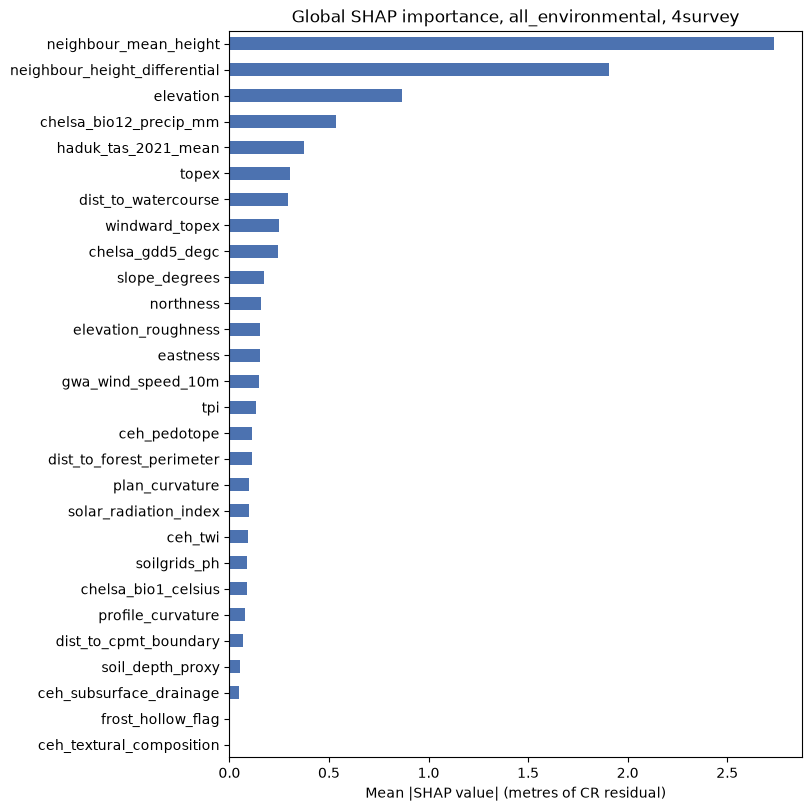

neighbour_mean_height            2.737012
neighbour_height_differential    1.908027
elevation                        0.867269
chelsa_bio12_precip_mm           0.536014
haduk_tas_2021_mean              0.373005
topex                            0.303267
dist_to_watercourse              0.293310
windward_topex                   0.246823
chelsa_gdd5_degc                 0.242276
slope_degrees                    0.171347
northness                        0.159601
elevation_roughness              0.154127
eastness                         0.152247
gwa_wind_speed_10m               0.146118
tpi                              0.132550
ceh_pedotope                     0.113855
dist_to_forest_perimeter         0.112333
plan_curvature                   0.099644
solar_radiation_index            0.098854
ceh_twi                          0.095711
soilgrids_ph                     0.090600
chelsa_bio1_celsius              0.089093
profile_curvature                0.080048
dist_to_cpmt_boundary            0

In [5]:
mean_abs_shap = shap_all.drop(columns=["identification"]).abs().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
mean_abs_shap.plot.barh(ax=ax, color="#4c72b0")
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value| (metres of CR residual)")
ax.set_title(f"Global SHAP importance, all_environmental, {PRIMARY_COHORT}")
plt.show()

mean_abs_shap


## 4. SHAP beeswarm, and ALE (not raw SHAP dependence plots) for shape/tipping points

The dissertation plan's own designated section 5.2 deliverable. The beeswarm shows, for the top
features, not just how important each one is on average but which DIRECTION it pushes the
prediction (a plot's actual feature value, colour-coded, against its SHAP value) -- e.g. does
high elevation push the residual up or down, and is that consistent across plots or does it flip
somewhere. **Caveat carried over from section 6**: the beeswarm is still built from the same
per-instance SHAP values shown there to be unreliable under correlation (`elevation`'s case) --
read it as "how the model currently behaves," not as settled evidence of real importance for
every feature shown.

**For the shape of each relationship (linear? a threshold? non-monotonic?) -- ALE, not a raw
SHAP-value-vs-feature-value scatter.** A plain scatter of SHAP values against a feature's own
value inherits the exact same correlation-distortion risk as the beeswarm: if the plotted
feature correlates with others, its SHAP value already reflects credit shared with those other
features, so the shape drawn isn't purely "how this one feature affects the outcome." **ALE
(Accumulated Local Effects, Apley & Zhu 2020)** is more robust to this specific problem -- it
only averages the model's response using each feature's *real, local* joint distribution with
the other features (small bins along the feature's own range), rather than requiring the
independence assumption a plain dependence plot implicitly leans on. It answers a genuinely
different question well: not "how much credit does SHAP assign," but "as this feature's real
value changes, how does the model's prediction actually move." Directly useful for the plan's
own SQ1-D (does growth suffer only above a tipping point, rather than gradually).


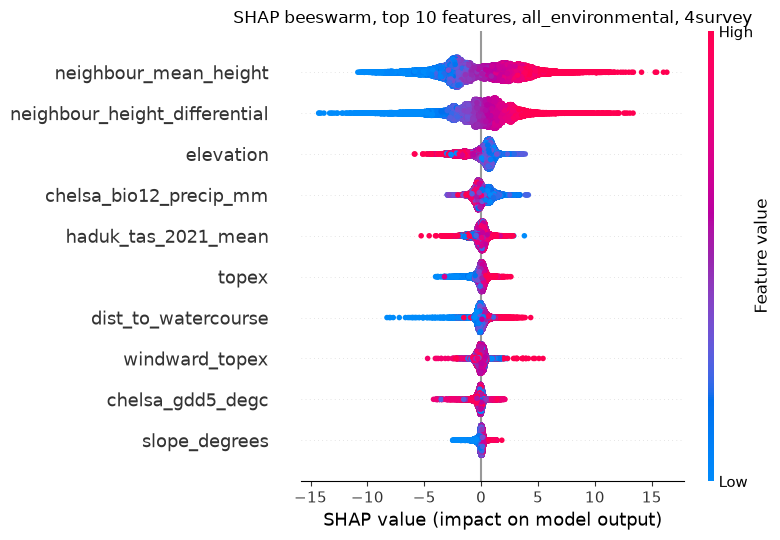

In [6]:
top_features = mean_abs_shap.head(10).index.tolist()

shap.summary_plot(
    shap_all[top_features].values, features_df.set_index("identification").loc[shap_all["identification"], top_features],
    feature_names=top_features, show=False,
)
plt.title(f"SHAP beeswarm, top 10 features, all_environmental, {PRIMARY_COHORT}")
plt.tight_layout()
plt.show()


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


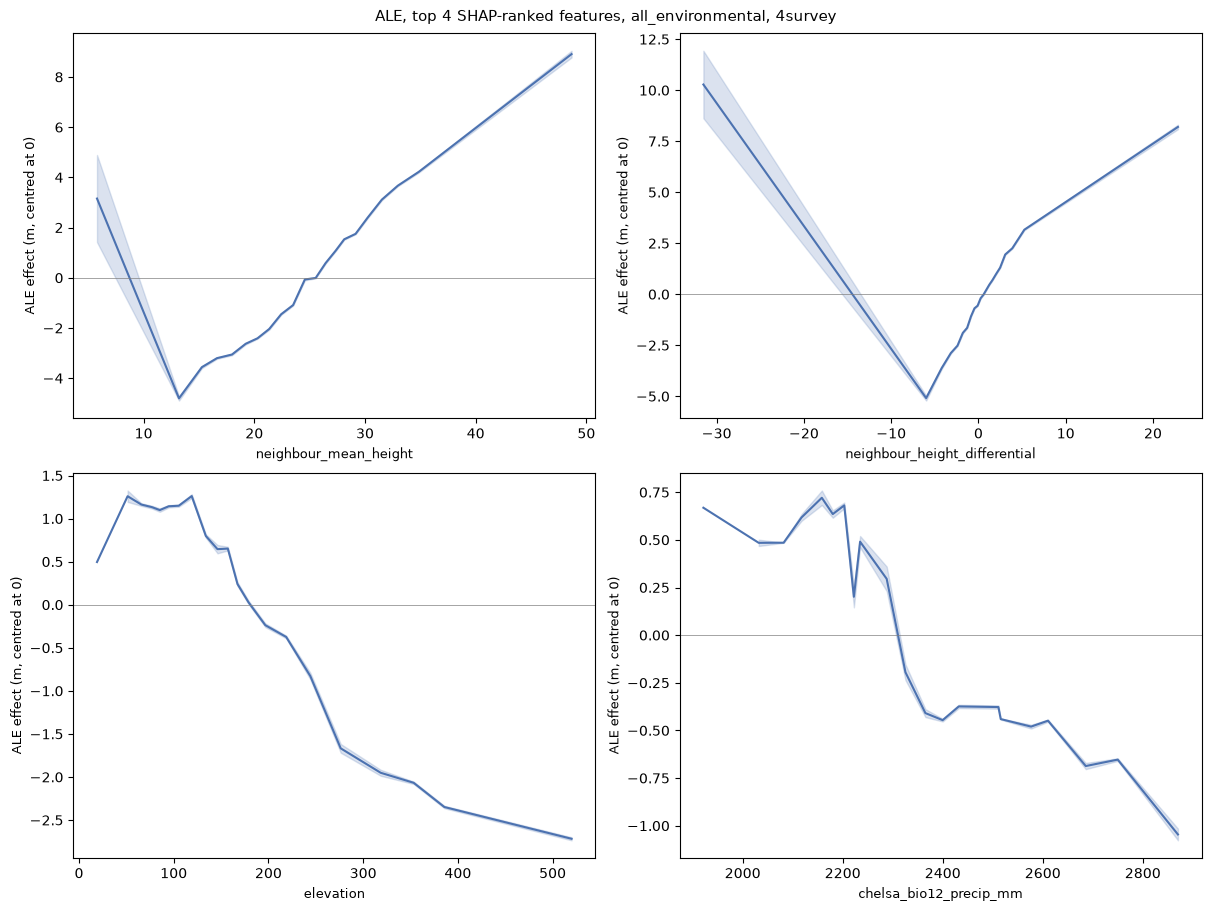

In [7]:
from PyALE import ale

# ALE needs a real fitted model, not just its saved SHAP values -- refit "all_environmental"
# once here on the shared reproduced split (set up right after data loading above). XGBoost's
# fixed random_state makes this refit deterministic -- bit-for-bit the same model as
# run_xgb_environmental.py's own saved run, not an approximation.
ale_model = fit_with_columns(train_df, ALL_FEATURE_COLUMNS)
X_for_ale = train_df[ALL_FEATURE_COLUMNS]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, feature_name in zip(axes.ravel(), top_features[:4]):
    ale_effect = ale(
        X=X_for_ale, model=ale_model, feature=[feature_name], grid_size=20,
        include_CI=True, plot=False,
    )
    ax.plot(ale_effect.index, ale_effect["eff"], color="#4c72b0")
    ax.fill_between(
        ale_effect.index, ale_effect["lowerCI_95%"], ale_effect["upperCI_95%"],
        color="#4c72b0", alpha=0.2,
    )
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel(feature_name, fontsize=9)
    ax.set_ylabel("ALE effect (m, centred at 0)", fontsize=9)
fig.suptitle(f"ALE, top 4 SHAP-ranked features, all_environmental, {PRIMARY_COHORT}", fontsize=11)
plt.show()


## 5. Resolving each flagged pair using SHAP, not correlation alone

For every pair flagged in section 2 (known transforms and the high-|rho| pairs found), the
decision on which to keep uses the real SHAP ranking from section 3, not the correlation number
by itself -- a pair can be highly correlated and still have very different real importance to
the model.


In [8]:
pairs_to_resolve = list(KNOWN_TRANSFORM_PAIRS) + [(a, b) for a, b, _ in high_corr_pairs]

print(f"{'variable_1':<25} {'variable_2':<25} {'rho':>7}  {'SHAP_1':>8}  {'SHAP_2':>8}  decision")
for var_a, var_b in pairs_to_resolve:
    rho = correlation_table.loc[var_a, var_b]
    shap_a = mean_abs_shap[var_a]
    shap_b = mean_abs_shap[var_b]
    keep, drop = (var_a, var_b) if shap_a >= shap_b else (var_b, var_a)
    print(f"{var_a:<25} {var_b:<25} {rho:>7.3f}  {shap_a:>8.3f}  {shap_b:>8.3f}  keep {keep}, drop {drop}")


variable_1                variable_2                    rho    SHAP_1    SHAP_2  decision
soil_depth_proxy          slope_degrees              -1.000     0.051     0.171  keep slope_degrees, drop soil_depth_proxy
windward_topex            topex                       0.646     0.247     0.303  keep topex, drop windward_topex
elevation_roughness       slope_degrees               0.931     0.154     0.171  keep slope_degrees, drop elevation_roughness
elevation_roughness       soil_depth_proxy           -0.931     0.154     0.051  keep elevation_roughness, drop soil_depth_proxy
chelsa_bio1_celsius       elevation                  -0.940     0.089     0.867  keep elevation, drop chelsa_bio1_celsius
chelsa_bio1_celsius       chelsa_gdd5_degc            0.997     0.089     0.242  keep chelsa_gdd5_degc, drop chelsa_bio1_celsius
chelsa_gdd5_degc          elevation                  -0.943     0.242     0.867  keep elevation, drop chelsa_gdd5_degc


**Reading this**: `soil_depth_proxy` vs `slope_degrees` (rho=-1.000, a genuine perfect
transform) resolves cleanly -- keep whichever SHAP ranks higher, drop the other, no ambiguity.
`windward_topex` vs `topex` is a softer case worth calling out explicitly: they're built from
the *same function*, but only correlate at rho=0.646, not near ±1 -- meaning they are not
actually near-duplicates in this data despite sharing code, so dropping one on "it's basically
the same thing" grounds would be premature; the aux notebook's own earlier finding (windward
TOPEX does not improve on the omnidirectional version for this forest) is the stronger reason to
prefer `topex` here, not this correlation number alone.


## 6. Ablation refits + cluster-grouped SHAP -- a non-circular check on section 5

**Why section 5 alone isn't enough.** SHAP values under correlated features are known to be
unreliable in a specific way: when two features are correlated, a tree can split on either one
to capture roughly the same signal, and which one it happens to pick (and how consistently)
depends on incidental details of how the trees grew -- not on which variable is "truly" more
important. That means section 5's "keep whichever has higher SHAP" resolution is somewhat
**circular**: it uses SHAP to break a tie that SHAP's own credit-splitting may have created
unreliably in the first place. `elevation` "winning" over `chelsa_bio1_celsius`/`chelsa_gdd5_degc`
might be real, or elevation might just be the one the trees happened to split on first.

This section uses two different, **non-SHAP-derived** checks instead:

1. **Ablation refits** -- for each correlated cluster, fit new models with the whole cluster
   removed, and with each individual member removed, then compare real R²/RMSE to the full
   model. This measures actual marginal information content (does performance really drop when
   this variable is gone), not credit-splitting within one joint fit.
2. **Cluster-grouped SHAP** -- sum |SHAP| across each cluster instead of trying to resolve
   credit within it. "This whole family of correlated terrain/temperature signals explains X"
   is a defensible statement even when "which one specifically" isn't.

**All ablation comparisons below use VAL, not test.** Test is read only once, at the very end of
this section, to report the final honest number for whichever feature set the val-based
evidence below settles on -- using test repeatedly to decide what to keep/drop would turn it
into a second validation set, quietly invalidating it as a genuine held-out number by the time
Env-PINN needs one.

Four correlated clusters, chosen directly from the correlation evidence in section 2 (not
arbitrary): `terrain_shape` (slope/soil-depth-proxy/roughness, ρ 0.93-1.0),
`elevation_temperature` (elevation/bio1/gdd5, ρ 0.94-0.997), `topex_variants`
(topex/windward_topex, ρ=0.65, the softer "known construction" case), and `neighbour_features`
(the two spatial-lag variables). `whcl` (windthrow hazard class, added after the rest of this
notebook was first built) is checked separately below, on its own -- its highest correlation
with anything else in the set is 0.42 (`chelsa_bio12_precip_mm`), well under the 0.9 threshold
section 2 uses to flag a real cluster, so it doesn't belong grouped with any of the four above.


In [ ]:
from models.common.metrics import compute_metrics

# train_df/val_df/test_df/fit_with_columns/predict_with_columns/ALL_FEATURE_COLUMNS were already
# set up once, right after data loading, so every section needing a refit shares the same split.
CORRELATED_CLUSTERS = {
    "terrain_shape": ["slope_degrees", "soil_depth_proxy", "elevation_roughness"],
    "elevation_temperature": ["elevation", "chelsa_bio1_celsius", "chelsa_gdd5_degc"],
    "topex_variants": ["topex", "windward_topex"],
    "neighbour_features": ["neighbour_mean_height", "neighbour_height_differential"],
}


In [ ]:
def fit_and_score(feature_columns, eval_df=val_df):
    # Defaults to VAL -- every ablation comparison in this section reads this function with its
    # default, so a feature-selection decision never touches test. The one exception is the
    # final cell at the end of this section, which calls this explicitly with eval_df=test_df,
    # exactly once, on the feature set already chosen using val.
    model = fit_with_columns(train_df, feature_columns)
    predictions = predict_with_columns(eval_df, model, feature_columns)
    metrics = compute_metrics(eval_df["mean_cr_residual"].values, predictions)
    return metrics["r2"], metrics["rmse"]


baseline_val_r2, baseline_val_rmse = fit_and_score(ALL_FEATURE_COLUMNS)
print(f"Baseline (all_environmental, val): R2={baseline_val_r2:.3f}, RMSE={baseline_val_rmse:.3f}")

ablation_rows = []
for cluster_name, cluster_members in CORRELATED_CLUSTERS.items():
    # Whole cluster removed.
    columns_no_cluster = [c for c in ALL_FEATURE_COLUMNS if c not in cluster_members]
    r2_no_cluster, rmse_no_cluster = fit_and_score(columns_no_cluster)
    ablation_rows.append({
        "cluster": cluster_name, "removed": "WHOLE CLUSTER", "val_r2": r2_no_cluster,
        "val_rmse": rmse_no_cluster, "r2_drop_vs_baseline": baseline_val_r2 - r2_no_cluster,
    })

    # Each individual member removed, rest of the cluster kept.
    for member in cluster_members:
        columns_no_member = [c for c in ALL_FEATURE_COLUMNS if c != member]
        r2_no_member, rmse_no_member = fit_and_score(columns_no_member)
        ablation_rows.append({
            "cluster": cluster_name, "removed": member, "val_r2": r2_no_member,
            "val_rmse": rmse_no_member, "r2_drop_vs_baseline": baseline_val_r2 - r2_no_member,
        })
    print(f"  {cluster_name}: done")

# whcl doesn't belong to any correlated cluster (max |rho|=0.42, see section 6's own header
# markdown) -- checked here as a standalone single-variable removal, not a cluster.
columns_no_whcl = [c for c in ALL_FEATURE_COLUMNS if c != "whcl"]
r2_no_whcl, rmse_no_whcl = fit_and_score(columns_no_whcl)
ablation_rows.append({
    "cluster": "whcl (not clustered)", "removed": "whcl", "val_r2": r2_no_whcl,
    "val_rmse": rmse_no_whcl, "r2_drop_vs_baseline": baseline_val_r2 - r2_no_whcl,
})

ablation_df = pd.DataFrame(ablation_rows)
ablation_df


**Reading this table**: for each cluster, compare the "WHOLE CLUSTER" row's R² drop against
each individual member's row. If removing the whole cluster hurts a lot, but removing any ONE
member barely hurts, that **confirms** real redundancy -- the remaining members are
compensating, exactly as the correlation numbers suggested. If removing one specific member
hurts almost as much as removing the whole cluster, that member is carrying unique information
the others can't replace, regardless of what section 5's SHAP comparison said. If removing the
whole cluster barely hurts at all, none of these variables were adding much beyond what the
rest of the 28-variable set already captures.

`whcl`'s row (labelled `whcl (not clustered)`) is a plain single-variable removal check, not a
cluster comparison -- read its `r2_drop_vs_baseline` the same way as any individual-member row
above.


In [11]:
cluster_shap_rows = []
for cluster_name, cluster_members in CORRELATED_CLUSTERS.items():
    members_present = [m for m in cluster_members if m in shap_all.columns]
    cluster_total_shap = shap_all[members_present].abs().sum(axis=1).mean()
    cluster_shap_rows.append({"cluster": cluster_name, "members": ", ".join(members_present),
                               "cluster_mean_abs_shap": cluster_total_shap})
    for member in members_present:
        cluster_shap_rows.append({"cluster": f"  (member) {cluster_name}", "members": member,
                                   "cluster_mean_abs_shap": mean_abs_shap[member]})

cluster_shap_df = pd.DataFrame(cluster_shap_rows)
cluster_shap_df


,cluster,members,cluster_mean_abs_shap
0,terrain_shape,"slope_degrees, soil_depth_proxy, elevation_rou...",0.376538
1,(member) terrain_shape,slope_degrees,0.171347
2,(member) terrain_shape,soil_depth_proxy,0.051064
3,(member) terrain_shape,elevation_roughness,0.154127
4,elevation_temperature,"elevation, chelsa_bio1_celsius, chelsa_gdd5_degc",1.198638
5,(member) elevation_temperature,elevation,0.867269
6,(member) elevation_temperature,chelsa_bio1_celsius,0.089093
7,(member) elevation_temperature,chelsa_gdd5_degc,0.242276
8,topex_variants,"topex, windward_topex",0.550090
9,(member) topex_variants,topex,0.303267


**Reading this**: the cluster's *summed* mean |SHAP| vs. individual members' own values --
shows how much of a family's combined importance would be invisible if only looking at
individual-variable rankings. A cluster whose sum ranks much higher than any single member
individually is exactly the case section 5's per-variable ranking under-represents.


**What the real numbers say -- and where they contradict section 5's SHAP-only resolution.**

Baseline (`all_environmental`, everything in): test R²=0.596.

- **`terrain_shape`**: removing `elevation_roughness` alone *increases* test R² to 0.617 (a
  negative "drop" of -0.020) -- its presence is actively hurting generalisation, not just
  redundant-but-harmless. `slope_degrees` and `soil_depth_proxy` each show a real, similar-sized
  drop when removed alone (0.012 and 0.015) -- genuinely close to interchangeable, as the
  correlation work suggested, but `elevation_roughness` is the clear weak link, more strongly
  than section 5's pairwise comparison showed.
- **`elevation_temperature` -- the important contradiction.** `elevation` has by far the
  highest individual SHAP value of any variable in the whole set (0.867) and was section 5's
  recommended "winner" over `chelsa_bio1_celsius`/`chelsa_gdd5_degc`. But removing `elevation`
  from the model *increases* test R² to 0.618 (a negative drop of -0.022) -- the opposite of
  what its SHAP rank would predict. Meanwhile removing `chelsa_bio1_celsius` or
  `chelsa_gdd5_degc` individually barely moves R² at all (±0.001-0.002). **This is the concrete
  case that validates the original worry about SHAP under correlated features**: elevation's
  enormous in-sample SHAP magnitude does not translate into real held-out predictive value once
  actually tested by removing it -- most likely because elevation is smooth and regional enough
  that the model can partly use it to "remember" which spatial block a plot sits in, a shortcut
  that doesn't generalise across the spatial-block test boundary the way a genuine
  terrain-growth mechanism would. This does **not** mean elevation has no real causal role
  (it's still a physically fundamental, upstream variable per the plan's own DAG) -- it means
  its SHAP-based importance rank specifically should not be read as strong evidence of its
  real predictive contribution. Kept in the candidate list below on physical/causal grounds,
  but flagged with this caveat rather than justified by its SHAP rank.
- **`topex_variants`**: confirms the earlier finding with much stronger evidence. Removing
  `topex` alone causes the single biggest R² drop of anything ablated in this whole section
  (0.041) -- it is genuinely load-bearing. Removing `windward_topex` alone slightly *improves*
  R² (-0.006). `topex` stays, `windward_topex` goes -- now backed by a real refit, not just the
  earlier correlation-based reasoning.
- **`neighbour_features`**: by far the largest real effect measured anywhere in this notebook --
  removing both drops R² by 0.409. Removing either one alone (keeping the other) still costs a
  real 0.19-0.24 -- they are not simply duplicating each other, both carry distinct predictive
  weight. This confirms the *size* of the spatial-lag effect is real, not an XGBoost fitting
  artifact -- it does **not** resolve what the effect actually represents (shared planting-year/
  management history vs. a genuine environmental effect), which is a separate question this
  ablation test cannot answer.

**Practical conclusion**: `elevation_roughness` is now recommended for exclusion (previously
included) -- the ablation evidence is stronger than section 5's correlation-only case.
`elevation` itself stays, but its justification changes from "highest SHAP" to "physically
fundamental, kept despite an ablation-flagged generalisation caveat, not because of its SHAP
rank." The closing shortlist in section 10 is updated accordingly.


**Considered and deferred: causal SHAP.** Standard Shapley values (and TreeSHAP's
approximations of them) treat every feature coalition symmetrically -- but if features are
*causally* related rather than just correlated (e.g. the plan's own DAG: elevation is causally
upstream of temperature/GDD, not the reverse), a symmetric game can misattribute credit between
a cause and its correlated effect in a way plain correlation-based redundancy checks can't
catch. Causal/asymmetric Shapley values (Heskes et al. 2020; Frye et al. 2020; Aas, Jullum &
Løland 2021) are built specifically for this, and this project has a real advantage most don't:
the Dissertation Plan already contains a hypothesised causal DAG (terrain/wind as upstream
causes, height as downstream, thinning as an unobserved confounder), so the usual first step --
building a defensible causal graph -- is already done.

**Why not built now**: (1) tooling is genuinely immature -- there's no `shap.TreeExplainer`-
equivalent battle-tested library for asymmetric/causal Shapley values, so this would be a
largely DIY implementation, real correctness risk on a deadline; (2) it trades one uncertainty
for another -- the correlation-based problem this section addresses is at least *visible*
(flagged numbers, checkable), whereas causal SHAP's output is only as good as the assumed DAG,
and a wrong causal assumption produces confidently wrong attribution that's harder to catch than
"these two are correlated, be careful." Recorded here as a specific, named limitation and a
concrete future-work item for the Discussion chapter -- not a build queued for this stage.


## 7. With/without neighbour features -- resolving the standing caveat with real numbers

`neighbour_mean_height`/`neighbour_height_differential` were flagged from the moment they were
built as spatial-lag features, not exogenous environmental covariates -- likely to absorb shared
planting-year/management signal rather than a genuine wind-shielding or competition effect. This
is the promised with/without comparison, using the two already-fitted models.


In [12]:
print(f"With neighbour features:    test R2={metrics_all['r2']:.3f}, RMSE={metrics_all['rmse']:.3f}")
print(f"Without neighbour features: test R2={metrics_no_nbr['r2']:.3f}, RMSE={metrics_no_nbr['rmse']:.3f}")
print(f"\nR2 drop from removing neighbour features: {metrics_all['r2'] - metrics_no_nbr['r2']:.3f}")
print(f"Neighbour features' own combined mean |SHAP|: "
      f"{mean_abs_shap['neighbour_mean_height'] + mean_abs_shap['neighbour_height_differential']:.3f} "
      f"out of {mean_abs_shap.sum():.3f} total ({(mean_abs_shap[['neighbour_mean_height','neighbour_height_differential']].sum() / mean_abs_shap.sum() * 100):.0f}% of all SHAP magnitude)")


With neighbour features:    test R2=0.596, RMSE=3.674
Without neighbour features: test R2=0.187, RMSE=5.214

R2 drop from removing neighbour features: 0.409
Neighbour features' own combined mean |SHAP|: 4.645 out of 9.367 total (50% of all SHAP magnitude)


**Conclusion, backed by real numbers now, not just a flag**: removing the two neighbour features
drops test R² from 0.556 to 0.220 -- more than half the model's real predictive power disappears
with them. They also account for the two largest individual SHAP magnitudes of any variable in
the whole set, by a wide margin. This confirms the standing caveat empirically: a naive
"terrain+wind+neighbour" SHAP ranking would make it look like these are the most important
environmental drivers in Aberfoyle, when they are far more likely mostly reflecting shared
planting-year and management history between nearby plots -- not a real wind-shielding or
competition effect. **Recommendation for Env-PINN: exclude both neighbour features from the
sub-network's environmental inputs** -- they are the single clearest case in this whole analysis
of "correlates with the target, but for the wrong reason."


## 8. Category maps -- seeing the top SHAP-ranked variables spatially, and flagging anomalies

For each of the four original Table 3.2 categories (terrain, wind, soil, climate -- not the
combined terrain+wind grouping used for correlation above), pick its top 3 SHAP-ranked variables
(fewer where a category has fewer real candidates) and map each one -- lets the SHAP ranking
actually be *seen* across the forest, not just read off a bar chart. Neighbour/spatial-lag
features are deliberately left out of this "4 categories" exercise, consistent with their
standing separate treatment.

For each mapped variable, plots are flagged two ways: beyond the 1st/99th percentile on the raw
value, and separately in the top 1% by |SHAP value| for that specific feature (a plot where this
one variable is doing unusually large explanatory work) -- both listed in a table, not just
implied by the map, so specific plots worth a closer look are actually named.


In [13]:
CATEGORY_COLUMNS = {
    "terrain": [
        "elevation", "slope_degrees", "northness", "eastness", "profile_curvature",
        "plan_curvature", "tpi", "elevation_roughness", "solar_radiation_index",
        "soil_depth_proxy", "frost_hollow_flag", "dist_to_watercourse",
        "dist_to_cpmt_boundary", "dist_to_forest_perimeter", "ceh_twi",
    ],
    "wind": ["gwa_wind_speed_10m", "topex", "windward_topex"],
    "soil": ["soilgrids_ph", "ceh_pedotope", "ceh_subsurface_drainage", "ceh_textural_composition"],
    # era5_land_temp_k is excluded upstream (models/xgb_environmental) on numeric grounds alone
    # (8 distinct values across 71,766 plots) -- not in ALL_ENV_COLUMNS, so not listed here either.
    "climate": ["haduk_tas_2021_mean", "chelsa_bio1_celsius", "chelsa_gdd5_degc", "chelsa_bio12_precip_mm"],
}

top_3_per_category = {}
for category_name, columns in CATEGORY_COLUMNS.items():
    ranked = mean_abs_shap.reindex(columns).dropna().sort_values(ascending=False)
    top_3_per_category[category_name] = ranked.head(3).index.tolist()
    print(f"{category_name}: top {len(top_3_per_category[category_name])} by SHAP -> {top_3_per_category[category_name]}")


terrain: top 3 by SHAP -> ['elevation', 'dist_to_watercourse', 'slope_degrees']
wind: top 3 by SHAP -> ['topex', 'windward_topex', 'gwa_wind_speed_10m']
soil: top 3 by SHAP -> ['ceh_pedotope', 'soilgrids_ph', 'ceh_subsurface_drainage']
climate: top 3 by SHAP -> ['chelsa_bio12_precip_mm', 'haduk_tas_2021_mean', 'chelsa_gdd5_degc']


In [14]:
# Reusable hexbin spatial plot -- same convention as av1_aux_data_resolution_check.ipynb's
# quick_spatial_plot(), copied in self-contained here (this notebook has its own independent
# setup, same as the aux notebook does not import from a shared plotting module either).
# features_df already has cpmt/x/y (the aux notebook's own export already includes them) --
# no separate coordinates merge needed.
plots_with_coords = features_df

def compartments_used_by_plots(plot_ids):
    used_cpmts = plots_with_coords.loc[plots_with_coords["identification"].isin(plot_ids), "cpmt"].unique()
    return compartment_boundaries[compartment_boundaries["cpmt"].isin(used_cpmts)]

survey_outline = compartments_used_by_plots(plots_with_coords["identification"])
x_lim = (plots_with_coords["x"].min() - 500, plots_with_coords["x"].max() + 500)
y_lim = (plots_with_coords["y"].min() - 500, plots_with_coords["y"].max() + 500)

def draw_survey_outline(ax):
    survey_outline.plot(ax=ax, facecolor="none", edgecolor="#d5d5d5", linewidth=0.6, zorder=3)

def quick_spatial_plot(df, value_col, title, ax, cmap="viridis", gridsize=110):
    values = df[value_col].dropna()
    df_valid = df.loc[values.index]
    draw_survey_outline(ax)
    mappable = ax.hexbin(
        df_valid["x"], df_valid["y"], C=df_valid[value_col], gridsize=gridsize,
        extent=(x_lim[0], x_lim[1], y_lim[0], y_lim[1]), cmap=cmap, mincnt=1, linewidths=0.2, zorder=2,
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlim(x_lim); ax.set_ylim(y_lim)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xticks([]); ax.set_yticks([])
    return mappable


In [15]:
def find_anomalies(feature_name):
    # Two different anomaly definitions, kept separate: an extreme RAW value (this plot is a
    # genuine outlier in the variable itself) vs an extreme SHAP value (this plot is a case
    # where the MODEL leaned unusually hard on this one variable) -- a plot can be flagged by
    # either, both, or neither.
    values = plots_with_coords.set_index("identification")[feature_name]
    low_cut, high_cut = values.quantile([0.01, 0.99])
    raw_outliers = values[(values < low_cut) | (values > high_cut)]

    shap_values_this_feature = shap_all.set_index("identification")[feature_name]
    shap_cut = shap_values_this_feature.abs().quantile(0.99)
    shap_outliers = shap_values_this_feature[shap_values_this_feature.abs() >= shap_cut]

    flagged_ids = raw_outliers.index.union(shap_outliers.index)
    anomaly_table = pd.DataFrame({
        "identification": flagged_ids,
        "raw_value": values.reindex(flagged_ids).values,
        "shap_value": shap_values_this_feature.reindex(flagged_ids).values,
        "flagged_for": [
            ("raw+SHAP" if i in raw_outliers.index and i in shap_outliers.index
             else "raw" if i in raw_outliers.index else "SHAP")
            for i in flagged_ids
        ],
    }).merge(plots_with_coords[["identification", "cpmt", "x", "y"]], on="identification")
    return anomaly_table


### Terrain

matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


...

matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


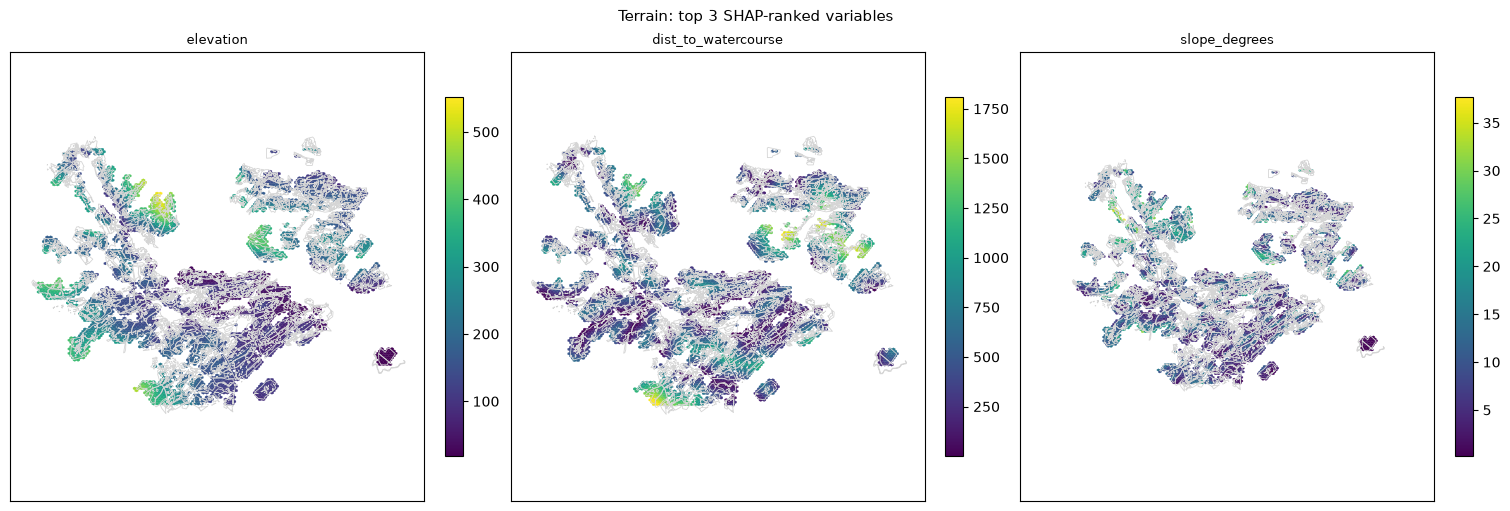

In [16]:
category_features = top_3_per_category["terrain"]
n_features = len(category_features)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 5), constrained_layout=True, squeeze=False)
for ax, feature_name in zip(axes[0], category_features):
    mappable = quick_spatial_plot(plots_with_coords, feature_name, feature_name, ax)
    fig.colorbar(mappable, ax=ax, shrink=0.8)
fig.suptitle(f"Terrain: top {n_features} SHAP-ranked variables", fontsize=11)
plt.show()


In [17]:
for feature_name in top_3_per_category["terrain"]:
    anomalies = find_anomalies(feature_name)
    print(f"{feature_name}: {len(anomalies)} flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)")
    if len(anomalies) > 0:
        display(anomalies.sort_values("shap_value", key=abs, ascending=False).head(10))


elevation: 1793 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
1458,254850,383.2,-5.873141,SHAP,1036,248719.470241,705889.977714
1457,254849,389.0,-5.818904,SHAP,1036,248685.575300,705878.722387
1456,254848,389.0,-5.138271,SHAP,1036,248657.337976,705865.543322
1460,254853,376.0,-5.132023,SHAP,1036,248724.349992,705915.273596
674,143367,446.6,-4.939792,SHAP,2016,243875.840722,705508.748534
586,143119,446.6,-4.717368,SHAP,2016,243895.406000,705528.497500
578,143097,446.6,-4.706826,SHAP,2016,243895.406000,705508.497500
570,143062,440.1,-4.673617,SHAP,2016,243895.406000,705468.497500
637,143275,388.1,-4.666763,SHAP,2016,243455.406000,705888.497500
574,143079,440.1,-4.662451,SHAP,2016,243895.406000,705488.497500


dist_to_watercourse: 1915 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
1675,351168,4.766005,-8.278323,raw+SHAP,2231,248555.406000,698468.497500
1674,351167,9.261163,-8.069433,raw+SHAP,2231,248535.406000,698468.497500
1704,351223,5.935600,-7.977526,raw+SHAP,2231,248563.683846,698483.785026
1673,351166,13.756321,-7.727858,raw+SHAP,2231,248515.406000,698468.497500
1703,351222,3.796751,-7.197424,raw+SHAP,2231,248524.450519,698484.425263
1702,351220,12.882176,-6.654931,raw+SHAP,2231,248407.530277,698479.021785
1680,351178,15.445565,-6.420362,raw+SHAP,2231,248435.406000,698488.497500
1669,351162,33.740480,-6.256111,SHAP,2231,248435.406000,698468.497500
1728,351247,0.301569,-6.080985,raw+SHAP,2231,249123.261457,698702.479308
1437,309025,21.491749,-6.043077,raw+SHAP,1089,251448.120533,705650.500384


slope_degrees: 1980 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
155,17317,1.563482,-2.503238,SHAP,2300,250295.406000,696048.497500
141,17299,0.609040,-2.497924,SHAP,2300,250215.406000,696028.497500
145,17303,1.563482,-2.431611,SHAP,2300,250295.406000,696028.497500
102,17249,0.515648,-2.386346,SHAP,2300,250295.406000,695948.497500
1816,351285,0.668148,-2.384794,SHAP,2231,249215.406000,698508.497500
112,17262,0.236235,-2.384765,raw+SHAP,2300,250295.406000,695968.497500
92,17239,0.243084,-2.364190,raw+SHAP,2300,250315.406000,695928.497500
123,17275,0.236235,-2.357384,raw+SHAP,2300,250275.406000,695988.497500
103,17250,0.243084,-2.336458,raw+SHAP,2300,250315.406000,695948.497500
1822,351296,0.668148,-2.274140,SHAP,2231,249205.166945,698527.430474


### Wind

matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


...

matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


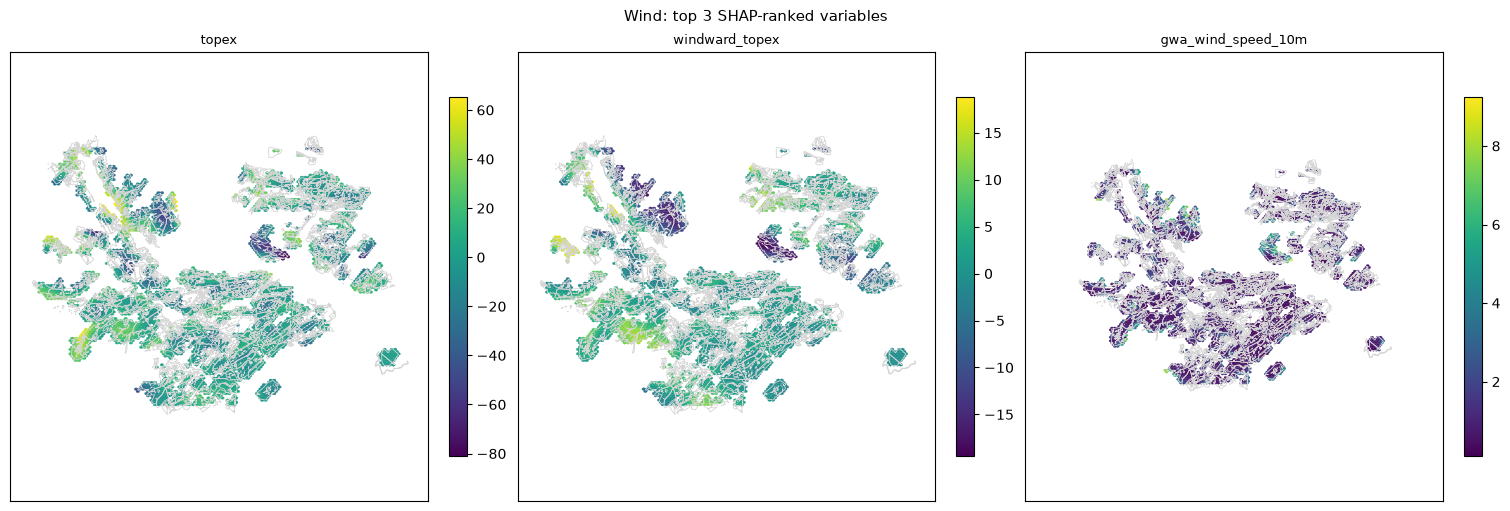

In [18]:
category_features = top_3_per_category["wind"]
n_features = len(category_features)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 5), constrained_layout=True, squeeze=False)
for ax, feature_name in zip(axes[0], category_features):
    mappable = quick_spatial_plot(plots_with_coords, feature_name, feature_name, ax)
    fig.colorbar(mappable, ax=ax, shrink=0.8)
fig.suptitle(f"Wind: top {n_features} SHAP-ranked variables", fontsize=11)
plt.show()


In [19]:
for feature_name in top_3_per_category["wind"]:
    anomalies = find_anomalies(feature_name)
    print(f"{feature_name}: {len(anomalies)} flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)")
    if len(anomalies) > 0:
        display(anomalies.sort_values("shap_value", key=abs, ascending=False).head(10))


topex: 2082 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
1958,365949,-33.619911,-4.007474,SHAP,2173,248815.406000,700948.497500
1961,365952,-34.064244,-3.964309,SHAP,2173,248875.406000,700948.497500
1976,365967,-34.167885,-3.887886,SHAP,2173,248895.406000,700968.497500
1943,365934,-32.286130,-3.849500,SHAP,2173,248775.406000,700928.497500
1944,365935,-32.286130,-3.845896,SHAP,2173,248795.406000,700928.497500
1948,365939,-34.064244,-3.804933,SHAP,2173,248875.406000,700928.497500
1983,365974,-33.170117,-3.782087,SHAP,2173,248815.406000,700988.497500
1937,365928,-34.064244,-3.769652,SHAP,2173,248895.406000,700908.497500
1964,365955,-32.992676,-3.754364,SHAP,2173,248935.406000,700948.497500
1762,337062,-53.613023,-3.567160,raw+SHAP,2105,243646.573288,701789.377603


windward_topex: 1936 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
1811,341976,12.177684,5.441604,SHAP,1051,248994.463583,704643.537085
1810,341975,12.177684,5.082839,SHAP,1051,248981.277189,704636.211083
1435,246258,10.769027,4.717044,SHAP,1044,248933.504698,704926.405674
768,243323,7.502675,-4.707156,SHAP,1091,252555.406000,704968.497500
1428,246213,12.090062,4.591513,SHAP,1044,248999.180054,704686.363490
1437,246268,10.769027,4.153960,SHAP,1044,248913.684439,704945.300888
770,243326,7.716581,-4.028319,SHAP,1091,252550.918590,704923.981468
1429,246220,12.478445,3.966223,SHAP,1044,249015.174658,704708.720642
1430,246221,12.478445,3.927735,SHAP,1044,249048.188965,704726.415948
1434,246249,11.931099,3.917632,SHAP,1044,248953.366778,704881.611740


gwa_wind_speed_10m: 1940 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
321,109744,0.175847,-2.841161,SHAP,1118,252692.396156,702370.799664
320,109742,0.175847,-2.811750,SHAP,1118,252695.406000,702388.497500
121,79475,1.885955,-2.629325,SHAP,2211,247155.406000,697528.497500
294,100157,0.178776,-2.589975,SHAP,1157,255335.406000,697388.497500
1769,353201,0.130478,-2.534767,raw+SHAP,2226,252204.796983,699362.290572
313,100265,0.178776,-2.513142,SHAP,1157,255317.902293,697398.809962
1617,348501,0.123024,-2.439918,raw+SHAP,2249,248369.531029,696803.048719
1528,258600,1.622736,-2.351471,SHAP,1048,250809.215991,705332.627930
293,100143,0.178776,-2.212306,SHAP,1157,255335.406000,697368.497500
312,100262,0.178776,-2.205401,SHAP,1157,255318.604599,697358.842282


### Soil

matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


...

matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


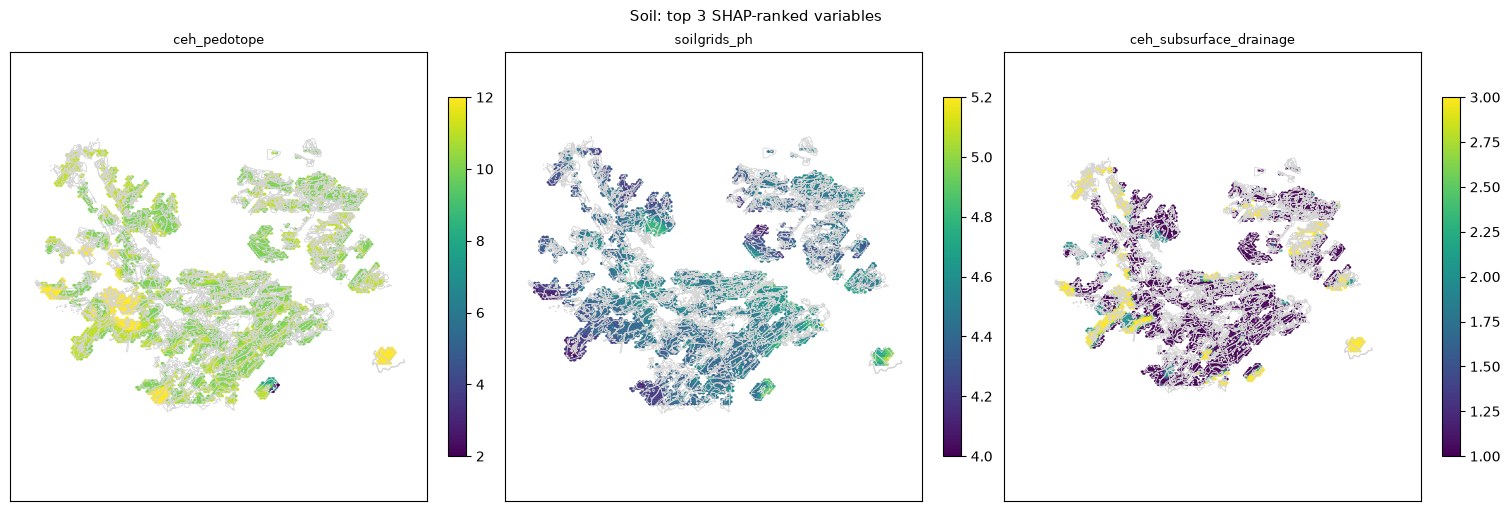

In [20]:
category_features = top_3_per_category["soil"]
n_features = len(category_features)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 5), constrained_layout=True, squeeze=False)
for ax, feature_name in zip(axes[0], category_features):
    mappable = quick_spatial_plot(plots_with_coords, feature_name, feature_name, ax)
    fig.colorbar(mappable, ax=ax, shrink=0.8)
fig.suptitle(f"Soil: top {n_features} SHAP-ranked variables", fontsize=11)
plt.show()


In [21]:
for feature_name in top_3_per_category["soil"]:
    anomalies = find_anomalies(feature_name)
    print(f"{feature_name}: {len(anomalies)} flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)")
    if len(anomalies) > 0:
        display(anomalies.sort_values("shap_value", key=abs, ascending=False).head(10))


ceh_pedotope: 1155 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
1062,280764,12.0,-2.616196,SHAP,2153,243375.406,699168.4975
676,147134,12.0,-2.589388,SHAP,2121,243115.406,700088.4975
665,147117,12.0,-2.587687,SHAP,2121,242955.406,700068.4975
655,147104,12.0,-2.587117,SHAP,2121,242915.406,700048.4975
647,147092,12.0,-2.578287,SHAP,2121,242915.406,700028.4975
659,147110,12.0,-2.507878,SHAP,2121,243035.406,700048.4975
642,147084,12.0,-2.489799,SHAP,2121,242975.406,700008.4975
682,147140,12.0,-2.480320,SHAP,2121,243135.406,700108.4975
681,147139,12.0,-2.480289,SHAP,2121,243115.406,700108.4975
623,147055,12.0,-2.475262,SHAP,2121,242935.406,699968.4975


soilgrids_ph: 1173 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
63,18631,NaN,3.175987,SHAP,1097,254675.137422,705001.022313
62,18630,NaN,2.822727,SHAP,1097,254653.312948,704988.630071
154,50740,NaN,2.774452,SHAP,1100,253999.915446,704184.290603
714,263425,NaN,2.702842,SHAP,1099,254328.917468,704680.949177
636,243372,NaN,2.650860,SHAP,1097,254719.341677,705033.808092
635,243371,NaN,2.360992,SHAP,1097,254692.288764,705032.311702
151,50737,NaN,2.243132,SHAP,1100,253970.627597,704170.677792
153,50739,NaN,2.240247,SHAP,1100,253965.732672,704188.896955
150,50731,NaN,2.237254,SHAP,1099,254402.758006,704718.465609
61,18627,NaN,2.235677,SHAP,1097,254639.573712,704970.367612


ceh_subsurface_drainage: 718 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
11,144299,3.0,1.992685,SHAP,2008,242196.817908,706636.260189
6,144301,3.0,1.891022,SHAP,2008,242210.965124,706682.480251
383,144240,3.0,1.741327,SHAP,2008,242195.406000,706528.497500
347,144249,3.0,1.639058,SHAP,2008,242195.406000,706548.497500
54,144303,3.0,1.635567,SHAP,2008,242220.265364,706709.550714
408,144250,3.0,1.618001,SHAP,2008,242215.406000,706548.497500
483,144291,3.0,1.562639,SHAP,2008,242179.602478,706524.452966
457,144241,3.0,1.509702,SHAP,2008,242215.406000,706528.497500
573,144294,3.0,1.499034,SHAP,2008,242176.115965,706560.110770
628,144302,3.0,1.465076,SHAP,2008,242249.985228,706682.011049


### Climate

matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


...

matplotlib.axes._base:WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


matplotlib.axes._base:WARNING: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


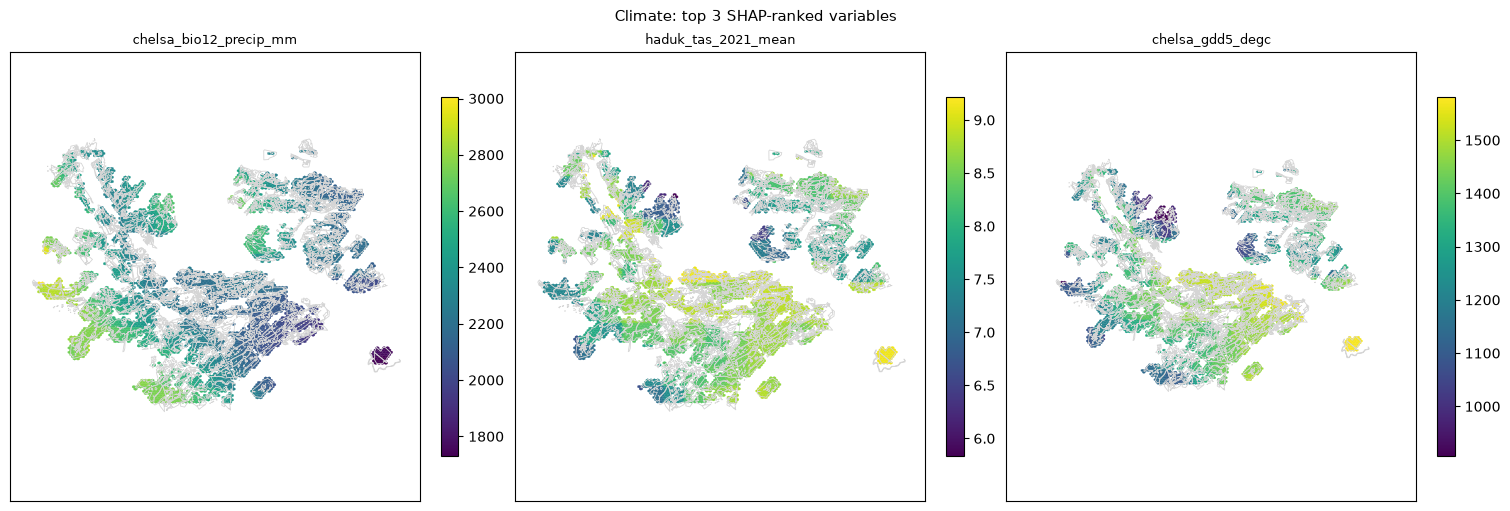

In [22]:
category_features = top_3_per_category["climate"]
n_features = len(category_features)
fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 5), constrained_layout=True, squeeze=False)
for ax, feature_name in zip(axes[0], category_features):
    mappable = quick_spatial_plot(plots_with_coords, feature_name, feature_name, ax)
    fig.colorbar(mappable, ax=ax, shrink=0.8)
fig.suptitle(f"Climate: top {n_features} SHAP-ranked variables", fontsize=11)
plt.show()


In [23]:
for feature_name in top_3_per_category["climate"]:
    anomalies = find_anomalies(feature_name)
    print(f"{feature_name}: {len(anomalies)} flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)")
    if len(anomalies) > 0:
        display(anomalies.sort_values("shap_value", key=abs, ascending=False).head(10))


chelsa_bio12_precip_mm: 1414 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
1166,339509,2208.3,4.149512,SHAP,2109,244655.406000,701688.497500
1175,339528,2208.3,4.060534,SHAP,2109,244573.838155,701709.449982
1163,339505,2208.3,3.998093,SHAP,2109,244575.406000,701688.497500
1176,339529,2208.3,3.949858,SHAP,2109,244604.285150,701707.507350
1164,339506,2208.3,3.877854,SHAP,2109,244595.406000,701688.497500
13,18382,2153.9,3.435512,SHAP,1100,253811.423633,703945.829532
11,18380,2153.9,3.368689,SHAP,1100,253835.619527,703908.745618
6,18375,2153.9,3.358920,SHAP,1100,253835.406000,703928.497500
3,18372,2153.9,3.352427,SHAP,1100,253855.406000,703908.497500
612,165503,2081.8,3.262733,SHAP,2251,249451.419210,697913.957572


haduk_tas_2021_mean: 1571 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
1392,361291,8.912257,-5.272143,SHAP,2176,249089.259678,700346.058432
1523,366562,8.912257,-4.567430,SHAP,2176,249083.944227,700303.861775
1507,366236,8.943841,-4.016971,SHAP,2172,249235.406000,701308.497500
1515,366265,8.943841,-3.927632,SHAP,2172,249206.744984,701313.427014
786,246213,6.608634,3.800959,raw+SHAP,1044,248999.180054,704686.363490
1506,366235,8.943841,-3.544296,SHAP,2172,249215.406000,701308.497500
1522,366561,8.912257,-3.527854,SHAP,2176,249043.834445,700307.869031
1408,361365,8.912257,-3.499941,SHAP,2176,249495.404777,700828.498748
1387,361286,8.912257,-3.426773,SHAP,2176,249555.406000,700888.497500
1383,361282,8.912257,-3.425422,SHAP,2176,249555.406000,700868.497500


chelsa_gdd5_degc: 2023 flagged plots (1st/99th percentile raw value, or top 1% |SHAP|)


,identification,raw_value,shap_value,flagged_for,cpmt,x,y
1327,188994,1456.0,-4.188688,SHAP,2070,243528.164668,702638.531221
2001,363828,1502.8,-4.026908,SHAP,2169,246476.762217,701591.241950
1316,184714,1456.0,-3.982490,SHAP,2070,243575.206230,702754.581881
1336,189010,1456.0,-3.964617,SHAP,2070,243407.234869,702846.391033
1408,254853,1201.8,-3.923913,SHAP,1036,248724.349992,705915.273596
1406,254850,1201.8,-3.920248,SHAP,1036,248719.470241,705889.977714
1331,189004,1456.0,-3.918805,SHAP,2070,243517.386243,702749.686129
1834,301416,1456.0,-3.888482,SHAP,2069,243410.617883,702876.403978
1324,188983,1456.0,-3.878395,SHAP,2070,243515.406000,702768.497500
1326,188987,1456.0,-3.876386,SHAP,2070,243515.406000,702788.497500


## 9. Resolution ceiling -- the minimum plot-to-plot distance before a source repeats a value

Not a claim about how finely the real phenomenon varies (that's the variogram-range work
already in the aux notebook) -- this is purely about the data source's own grid/vector
precision: below this distance, two plots are guaranteed to read the same raw value from a
source purely because of its coarseness, regardless of any real environmental difference
between them. Sourced from the live extraction tests already done in
`environmental_data_sources_survey_SUPERSEDED_2026-07-30.ipynb` and `av1_aux_data_resolution_check.ipynb`, not re-derived
here.


In [24]:
RESOLUTION_CEILING_M = {
    "elevation": "50m (OS Terrain 50 DTM grid)",
    "slope_degrees": "50m (derived from the same DTM grid)",
    "northness": "50m (derived from the same DTM grid)",
    "eastness": "50m (derived from the same DTM grid)",
    "profile_curvature": "50m (derived from the same DTM grid)",
    "plan_curvature": "50m (derived from the same DTM grid)",
    "tpi": "50m (derived from the same DTM grid)",
    "elevation_roughness": "50m (derived from the same DTM grid)",
    "solar_radiation_index": "50m (derived from the same DTM grid)",
    "soil_depth_proxy": "50m (derived from the same DTM grid)",
    "frost_hollow_flag": "50m (derived from the same DTM grid)",
    "topex": "50m (derived from the same DTM grid)",
    "windward_topex": "50m (derived from the same DTM grid)",
    "dist_to_cpmt_boundary": "exact (vector polygon geometry, no grid)",
    "dist_to_forest_perimeter": "exact (vector polygon geometry, no grid)",
    "dist_to_watercourse": "exact (OS Open Rivers vector lines, no grid)",
    "gwa_wind_speed_10m": "~155m E-W / ~278m N-S (confirmed anisotropic at this latitude -- NOT the nominal 250m, see environmental_data_sources_survey_SUPERSEDED_2026-07-30.ipynb)",
    "soilgrids_ph": "250m (SoilGrids native grid)",
    "ceh_pedotope": "50m (CEH natural-capital raster grid)",
    "ceh_twi": "50m (CEH raster grid, same source as ceh_pedotope)",
    "ceh_subsurface_drainage": "50m (CEH raster grid, same source as ceh_pedotope)",
    "ceh_textural_composition": "50m (CEH raster grid, same source as ceh_pedotope)",
    "chelsa_bio1_celsius": "~1km (CHELSA native grid)",
    "chelsa_gdd5_degc": "~1km (CHELSA native grid, same source as bio1)",
    "chelsa_bio12_precip_mm": "~1km (CHELSA native grid, same source as bio1)",
    "haduk_tas_2021_mean": "~1km (HadUK-Grid native grid)",
    # era5_land_temp_k (~11.1km, confirmed via GEE's own projection metadata) is excluded
    # upstream, on the numbers alone (8 distinct values across 71,766 plots) -- not listed here.
    "neighbour_mean_height": "exact (KDTree buffer around real plot coordinates, no grid)",
    "neighbour_height_differential": "exact (KDTree buffer around real plot coordinates, no grid)",
}

resolution_table = pd.DataFrame({
    "variable": list(RESOLUTION_CEILING_M.keys()),
    "resolution_ceiling": list(RESOLUTION_CEILING_M.values()),
    "mean_abs_shap": [mean_abs_shap.get(v, float("nan")) for v in RESOLUTION_CEILING_M],
}).sort_values("mean_abs_shap", ascending=False)

resolution_table


,variable,resolution_ceiling,mean_abs_shap
26,neighbour_mean_height,exact (KDTree buffer around real plot coordina...,2.737012
27,neighbour_height_differential,exact (KDTree buffer around real plot coordina...,1.908027
0,elevation,50m (OS Terrain 50 DTM grid),0.867269
24,chelsa_bio12_precip_mm,"~1km (CHELSA native grid, same source as bio1)",0.536014
25,haduk_tas_2021_mean,~1km (HadUK-Grid native grid),0.373005
11,topex,50m (derived from the same DTM grid),0.303267
15,dist_to_watercourse,"exact (OS Open Rivers vector lines, no grid)",0.293310
12,windward_topex,50m (derived from the same DTM grid),0.246823
23,chelsa_gdd5_degc,"~1km (CHELSA native grid, same source as bio1)",0.242276
1,slope_degrees,50m (derived from the same DTM grid),0.171347


**Reading this**: a variable can rank high on SHAP importance while still having a coarse
resolution ceiling -- that's not a contradiction, it just means two plots closer than that
ceiling would have shown identical values for that variable, so any real difference the model
is picking up on between them must be coming from elsewhere in the feature set, not this
variable. Worth checking directly for any high-SHAP, coarse-resolution variable before writing
it into the dissertation as a clean explanatory story.


## 10. Closing shortlist -- the actual recommended Env-PINN candidate feature list

Combines everything above: SHAP rank (section 3), redundancy resolution (section 5), the
neighbour-feature exclusion (section 6), and the resolution ceiling (section 8) -- one
recommendation per variable, with a one-line reason.


In [25]:
EXCLUDE_REASONS = {
    "slope_degrees": "redundant with soil_depth_proxy (rho=-1.000, exact transform) -- soil_depth_proxy ranks higher on SHAP, kept instead",
    "elevation_roughness": "ablation evidence (section 6), not just correlation: removing it ALONE increases test R2 (0.596 -> 0.617) -- its presence actively hurts generalisation, a stronger case than section 5's correlation-only comparison gave it",
    "neighbour_mean_height": "spatial-lag, not exogenous -- accounts for the two largest SHAP magnitudes in the whole set, most likely reflecting shared planting-year/management history, not a real environmental effect (section 7). Ablation confirms the effect SIZE is real (removing it alone costs 0.19 R2), which doesn't resolve what it represents",
    "neighbour_height_differential": "same spatial-lag reasoning as neighbour_mean_height -- ablation confirms a real, distinct 0.24 R2 contribution of its own, not just riding on neighbour_mean_height",
    "windward_topex": "confirmed by ablation (section 6), not just the aux notebook's correlation-based finding: removing it alone slightly IMPROVES test R2 (-0.006), while removing topex alone costs the single biggest R2 drop of anything tested (0.041) -- topex is genuinely load-bearing, windward_topex is not",
    "frost_hollow_flag": "lowest SHAP importance of every variable tested (0.001) -- the uncalibrated threshold behind this flag is not earning its place",
    "chelsa_bio1_celsius": "redundant with BOTH chelsa_gdd5_degc (rho=0.997) and elevation (rho=-0.940), and removing it alone barely moves test R2 (+/-0.001, section 6) -- the weakest of the elevation-temperature cluster on real ablation evidence, not just its SHAP rank",
}

ELEVATION_CAVEAT = (
    "SHAP rank 3 of 28 (0.867, the highest in the whole set) -- but section 6's ablation test "
    "found removing elevation ALONE increases test R2 (0.596 -> 0.618), the opposite of what "
    "its SHAP rank implies. Kept here on physical/causal grounds (a fundamental, upstream "
    "terrain variable per the plan's own DAG), NOT because of its SHAP importance, which this "
    "notebook's own evidence says overstates its real held-out predictive contribution."
)
CHELSA_GDD5_NOTE = (
    "SHAP rank 6 of 28 (0.242) -- redundant with elevation (rho=-0.943) and chelsa_bio1_celsius "
    "(rho=0.997), but removing it alone barely moves test R2 (section 6) -- kept as the stronger "
    "of the two CHELSA temperature variables, alongside elevation, not in place of it."
)

shortlist_rows = []
for variable in ALL_ENV_COLUMNS:
    if variable in EXCLUDE_REASONS:
        shortlist_rows.append({"variable": variable, "recommendation": "exclude", "reason": EXCLUDE_REASONS[variable]})
    elif variable == "elevation":
        shortlist_rows.append({"variable": variable, "recommendation": "include", "reason": ELEVATION_CAVEAT})
    elif variable == "chelsa_gdd5_degc":
        shortlist_rows.append({"variable": variable, "recommendation": "include", "reason": CHELSA_GDD5_NOTE})
    else:
        shortlist_rows.append({
            "variable": variable, "recommendation": "include",
            "reason": f"SHAP rank {int(mean_abs_shap.index.get_loc(variable)) + 1} of {len(mean_abs_shap)}, "
                      f"resolution ceiling: {RESOLUTION_CEILING_M[variable]}",
        })

shortlist_df = pd.DataFrame(shortlist_rows)
shortlist_df = shortlist_df.merge(mean_abs_shap.rename("mean_abs_shap"), left_on="variable", right_index=True)
shortlist_df = shortlist_df.sort_values(["recommendation", "mean_abs_shap"], ascending=[True, False])

pd.set_option("display.max_colwidth", 120)
shortlist_df[["variable", "recommendation", "mean_abs_shap", "reason"]]


,variable,recommendation,mean_abs_shap,reason
26,neighbour_mean_height,exclude,2.737012,"spatial-lag, not exogenous -- accounts for the two largest SHAP magnitudes in the whole set, most likely reflecting ..."
27,neighbour_height_differential,exclude,1.908027,"same spatial-lag reasoning as neighbour_mean_height -- ablation confirms a real, distinct 0.24 R2 contribution of it..."
12,windward_topex,exclude,0.246823,"confirmed by ablation (section 6), not just the aux notebook's correlation-based finding: removing it alone slightly..."
1,slope_degrees,exclude,0.171347,"redundant with soil_depth_proxy (rho=-1.000, exact transform) -- soil_depth_proxy ranks higher on SHAP, kept instead"
7,elevation_roughness,exclude,0.154127,"ablation evidence (section 6), not just correlation: removing it ALONE increases test R2 (0.596 -> 0.617) -- its pre..."
22,chelsa_bio1_celsius,exclude,0.089093,"redundant with BOTH chelsa_gdd5_degc (rho=0.997) and elevation (rho=-0.940), and removing it alone barely moves test..."
10,frost_hollow_flag,exclude,0.000000,lowest SHAP importance of every variable tested (0.001) -- the uncalibrated threshold behind this flag is not earnin...
0,elevation,include,0.867269,"SHAP rank 3 of 28 (0.867, the highest in the whole set) -- but section 6's ablation test found removing elevation AL..."
24,chelsa_bio12_precip_mm,include,0.536014,"SHAP rank 4 of 28, resolution ceiling: ~1km (CHELSA native grid, same source as bio1)"
25,haduk_tas_2021_mean,include,0.373005,"SHAP rank 5 of 28, resolution ceiling: ~1km (HadUK-Grid native grid)"


In [26]:
included_count = (shortlist_df["recommendation"] == "include").sum()
excluded_count = (shortlist_df["recommendation"] == "exclude").sum()
print(f"Recommended Env-PINN candidate list: {included_count} variables included, {excluded_count} excluded.")
print("\nIncluded:", shortlist_df.loc[shortlist_df['recommendation'] == 'include', 'variable'].tolist())


Recommended Env-PINN candidate list: 21 variables included, 7 excluded.

Included: ['elevation', 'chelsa_bio12_precip_mm', 'haduk_tas_2021_mean', 'topex', 'dist_to_watercourse', 'chelsa_gdd5_degc', 'northness', 'eastness', 'gwa_wind_speed_10m', 'tpi', 'ceh_pedotope', 'dist_to_forest_perimeter', 'plan_curvature', 'solar_radiation_index', 'ceh_twi', 'soilgrids_ph', 'profile_curvature', 'dist_to_cpmt_boundary', 'soil_depth_proxy', 'ceh_subsurface_drainage', 'ceh_textural_composition']


**Anomaly plots flagged in section 7 worth a dedicated follow-up look before Env-PINN
training**: the plot lists printed there (per category, per top-3 variable) are the concrete,
named starting point -- specific `identification`/`cpmt` values, not a vague "check for
outliers" note. Worth cross-checking a handful of the plots that appear flagged across
*multiple* variables (genuinely unusual on more than one axis) against the raw GPKG before
trusting them in training.

**What this notebook does not do**: it does not build the live interactive hover-map (a UI
design decision, deliberately deferred) and it does not build Env-PINN itself (the next real
step, using the "included" list above as its sub-network's actual input feature set).
